In [6]:
import import_ipynb
import genetic_algorithm
import NSGA2
import simulated_annealing
from accuracy import calc_accuracy
from knn_evaluator import evaluate_knn
from random_forest_evaluator import evaluate_random_forest
import pandas as pd
import numpy as np

In [7]:
X_train_toxicity = pd.read_csv("../datasets/oral_toxicity/X_train.csv")
X_validation_toxicity = pd.read_csv("../datasets/oral_toxicity/X_validation.csv")
y_train_toxicity = pd.read_csv('../datasets/oral_toxicity/y_train.csv').to_numpy().ravel()
y_validation_toxicity  = pd.read_csv('../datasets/oral_toxicity/y_validation.csv').to_numpy().ravel()

In [8]:
# type(y_validation_toxicity.to_numpy().ravel())

0.9228630993745657 0.041015625
0.9200833912439194 0.037109375
0.9284225156358582 0.064453125
0.936761640027797 0.0693359375
0.9263377345378735 0.052734375
0.925642807505212 0.0498046875
0.9374565670604587 0.109375
0.9381514940931203 0.1474609375


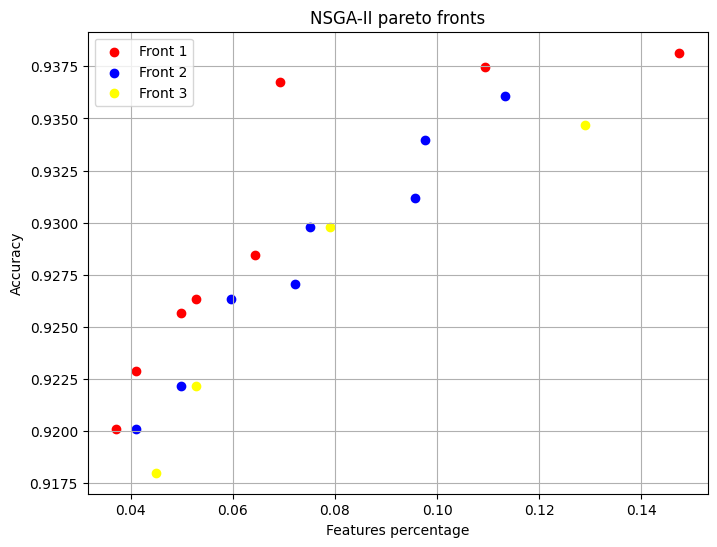

In [9]:
nsga = NSGA2.NSGA2(X_train_toxicity, y_train_toxicity, X_validation_toxicity, y_validation_toxicity, calc_accuracy_fn=evaluate_random_forest,
                   population_size=20, num_generations=3, feature_probability=0.05)
pareto = nsga.run()

In [11]:
sa =simulated_annealing.Simulated_Annealing(30,pareto[0].code,0.5,X_train_toxicity,y_train_toxicity,X_validation_toxicity,y_validation_toxicity,evaluate_random_forest)
sol, fitness,selected_percentage=sa.run()

In [12]:
fitness

0.9423135912526059

In [13]:
selected_percentage

0.041015625

In [15]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,X_validation_toxicity,y_validation_toxicity,calc_accuracy_fn= evaluate_random_forest, population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10,use_heuristic = False)
selected_features, fitness, history,population = ga.run()

In [23]:
fitness

0.938836512986449

In [15]:
#type(X_train_toxicity[X_train_toxicity.columns[selected_features]].to_numpy())

numpy.ndarray

In [21]:
X_test_toxicity = pd.read_csv("../datasets/oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../datasets/oral_toxicity/y_test.csv").to_numpy().ravel()

In [22]:
evaluate_random_forest(selected_features,X_train_toxicity,y_train_toxicity,X_test_toxicity,y_test_toxicity)

0.933852140077821

In [24]:
X_train_leukemia = pd.read_csv("../datasets/leukemia/X_train.csv")
X_validation_leukemia = pd.read_csv("../datasets/leukemia/X_validation.csv")

y_train_leukemia = pd.read_csv("../datasets/leukemia/y_train.csv").to_numpy().ravel()
y_validation_leukemia = pd.read_csv("../datasets/leukemia/y_validation.csv").to_numpy().ravel()

In [32]:
ga = genetic_algorithm.GA( X_train_leukemia ,y_train_leukemia ,X_validation_leukemia,y_validation_leukemia,calc_accuracy_fn= evaluate_random_forest , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10,use_heuristic = True)
selected_features, fitness, history, population = ga.run()

No improvement for 10 generations


In [5]:
X_test_leukemia = pd.read_csv("../datasets/leukemia/X_test.csv")
y_test_leukemia = pd.read_csv("../datasets/leukemia/y_test.csv").to_numpy().ravel()

In [6]:
evaluate_knn(selected_features,X_train_leukemia,y_train_leukemia,X_test_leukemia,y_test_leukemia)

0.9333333333333333

In [7]:
fitness

0.8920570907560668

In [ ]:
ga = genetic_algorithm.GA( X_train_leukemia ,y_train_leukemia ,X_validation_leukemia,y_validation_leukemia,calc_accuracy_fn= evaluate_random_forest , population_size = 30, num_generations = 50, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 3,patience = 10,use_heuristic = True)
selected_features, fitness, history,population = ga.run()

In [ ]:
fitness

In [35]:
evaluate_random_forest(selected_features,X_train_leukemia,y_train_leukemia,X_test_leukemia,y_test_leukemia)

0.8

In [36]:
X_train_madelon = pd.read_csv("../datasets/madelon/X_train.csv")
X_validation_madelon = pd.read_csv("../datasets/madelon/X_validation.csv")
y_train_madelon = pd.read_csv('../datasets/madelon/y_train.csv').to_numpy().ravel()
y_validation_madelon  = pd.read_csv('../datasets/madelon/y_validation.csv').to_numpy().ravel()
X_test_madelon = pd.read_csv("../datasets/madelon/X_test.csv")
y_test_madelon = pd.read_csv("../datasets/madelon/y_test.csv").to_numpy().ravel()

In [42]:
ga = genetic_algorithm.GA( X_train_madelon ,y_train_madelon ,X_validation_madelon,y_validation_madelon,calc_accuracy_fn= evaluate_random_forest , population_size = 50, num_generations = 30, tournament_size=5, mutation_probability = 0.1,alpha = 0.5,elitism_size = 5,patience = 10,use_heuristic = False)
selected_features, fitness, history,population = ga.run()

No improvement for 10 generations


In [43]:
fitness

0.80125

In [44]:
sum(selected_features)

55

In [45]:
evaluate_random_forest(selected_features,X_train_madelon,y_train_madelon,X_test_madelon,y_test_madelon)

0.65

In [46]:
evaluate_knn(selected_features,X_train_madelon,y_train_madelon,X_test_madelon,y_test_madelon)

0.5725

In [66]:
ga1 = genetic_algorithm.GA( X_train_madelon ,y_train_madelon ,X_validation_madelon,y_validation_madelon,calc_accuracy_fn= evaluate_knn , population_size = 100, num_generations = 30, tournament_size=5, mutation_probability = 0.1,alpha = 0.5,elitism_size = 5,patience = 100,use_heuristic = True)
selected_features1, fitness1, history1,population1 = ga1.run()

In [67]:
fitness1

0.8091875

In [68]:
sum(selected_features1)

8

In [69]:
evaluate_knn(selected_features1,X_train_madelon,y_train_madelon,X_test_madelon,y_test_madelon)

0.595

In [49]:
def most_frequent_features(population):
    solutions = np.array([individual.code for individual in population])
    counts = solutions.sum(axis=0)
    ranked = np.argsort(counts)[::-1]
    return counts,ranked

In [52]:
#most_frequent_features(population) #da li da je ovo koristi dalje mozda vizuelizovati 